In [38]:
import joblib
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [39]:
rf2017_path = "models/random_forest_cicids2017.joblib"
rf2023_path = "models/random_forest_ciciot2023.joblib"

model_cicids = joblib.load(rf2017_path)["model"]
model_ciciot = joblib.load(rf2023_path)["model"]

print("Loaded both models.")

Loaded both models.


In [40]:
df_cicids2017 = pd.read_csv("../data/CICIDS2017/wednesday_labeled.csv")

In [41]:
df_ciciot2023 = pd.read_csv("../data/CICIoT2023/ciciot2023_labeled_conn.csv",on_bad_lines="skip")

In [42]:
label_column = "label"

X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

In [43]:
print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

print("Model CICIDS expects:", getattr(model_cicids, "n_features_in_", "unknown"))
print("Model CICIoT expects:", getattr(model_ciciot, "n_features_in_", "unknown"))

CICIDS test shape: (509391, 10)
CICIoT test shape: (1840750, 16)
Model CICIDS expects: 5
Model CICIoT expects: 39


In [44]:
X_ciciot = X_ciciot[["proto", "duration", "orig_bytes", "resp_bytes", "conn_state"]]

In [45]:
# Encode non-numerical features
categorical_cols = X_ciciot.select_dtypes(include=["object"]).columns
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_ciciot[categorical_cols] = encoder.fit_transform(X_ciciot[categorical_cols])

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_13636\4055945930.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_ciciot.select_dtypes(include=["object"]).columns


In [46]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Generic evaluation function for binary or multiclass classification.

    Parameters:
    -----------
    y_true : array-like
    y_pred : array-like
    model_name : str (for plot title)
    """
    if hasattr(y_true, "cpu"):
        y_true = y_true.cpu().numpy()
    if hasattr(y_pred, "cpu"):
        y_pred = y_pred.cpu().numpy()

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true_str = y_true.astype(str)
    y_pred_str = y_pred.astype(str)

    all_labels = np.unique(np.concatenate([y_true_str, y_pred_str]))

    print(f"\n=== {model_name} Classification Report ===\n")
    print(classification_report(y_true_str, y_pred_str, labels=all_labels, digits=4))

    cm = confusion_matrix(y_true_str, y_pred_str, labels=all_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=all_labels, yticklabels=all_labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix (counts)")
    plt.tight_layout()
    plt.show()

In [47]:
y_pred_cicids_on_ciciot = model_cicids.predict(X_ciciot)


=== CICIDS2017-trained model tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1877    0.9937    0.3157    345418
DoS-HTTP_Flood     0.8173    0.0066    0.0130   1495332

      accuracy                         0.1918   1840750
     macro avg     0.5025    0.5001    0.1644   1840750
  weighted avg     0.6991    0.1918    0.0698   1840750



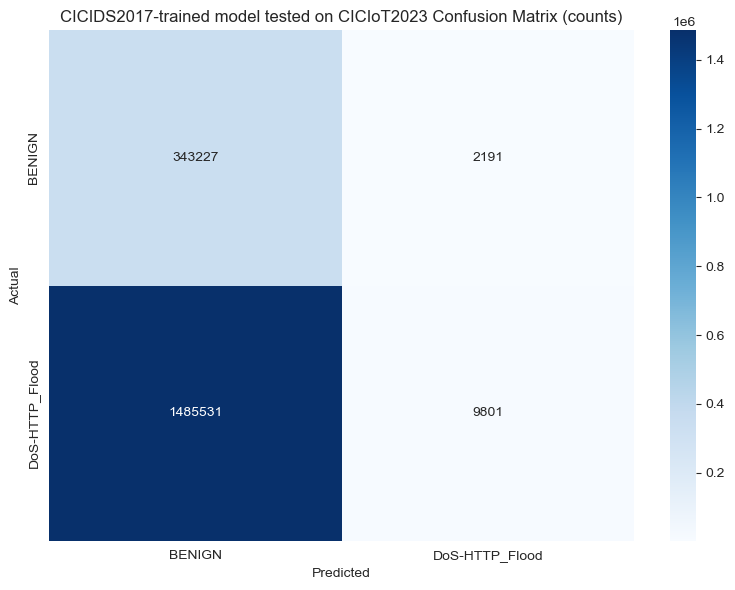

In [48]:
evaluate_model(
    y_true=y_ciciot,
    y_pred=model_cicids.predict(X_ciciot),
    model_name="CICIDS2017-trained model tested on CICIoT2023"
)